# Gradient-Flow Simulation: Figure 10

This notebook was added for Appendix B.4. Figure 10 is not a W&B experiment; it is a numerical simulation of the population gradient-flow dynamics from Equation (4), with `d=50`, `T=40`, `h=3`, singleton intervals, `m=1.7`, and no weight decay.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from analysis.utils import REPORT_HEAD_COLORS, REPORT_LINEWIDTH, style_report_axis


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


## Simulate The Tensor-Factorization Dynamics

The simulation works in the orthonormal feature basis used by the analysis. The state tracks each head's feature vector `V_k`, attention distribution `s_k`, and the residual tensor `G - P`.


In [2]:
def simulate_gradient_flow(seed=0, dt=0.005, steps=100_000, record_every=100):
    rng = np.random.default_rng(seed)
    h, T = 3, 40
    m = 1.7
    strengths = np.array([m**2, m, 1.0])
    positions = np.array([0, 1, 2])

    G = np.zeros((h, T))
    for j, (strength, position) in enumerate(zip(strengths, positions)):
        G[j, position] = strength

    V = np.zeros((h, h))
    s = np.full((h, T), 1 / T) + 1e-6 * rng.normal(size=(h, T))
    s = np.clip(s, 1e-12, None)
    s /= s.sum(axis=1, keepdims=True)

    records = []
    time = 0.0
    for step in range(steps + 1):
        if step % record_every == 0:
            P = sum(np.outer(V[k], s[k]) for k in range(h))
            residual = G - P
            loss = 0.5 * np.sum(residual * residual)
            contributions = []
            for j, (strength, position) in enumerate(zip(strengths, positions)):
                pred = sum(V[k, j] * s[k, position] for k in range(h))
                contributions.append(0.5 * (strength - pred) ** 2)
            records.append(
                {
                    "time": time,
                    "V": V.copy(),
                    "s": s.copy(),
                    "loss": loss,
                    "contributions": np.array(contributions),
                }
            )

        P = sum(np.outer(V[k], s[k]) for k in range(h))
        residual = G - P
        V_dot = np.zeros_like(V)
        s_dot = np.zeros_like(s)
        for k in range(h):
            V_dot[k] = residual @ s[k]
            raw_s_dot = V[k] @ residual
            projection = np.diag(s[k]) - np.outer(s[k], s[k])
            s_dot[k] = projection @ raw_s_dot

        V += dt * V_dot
        s += dt * s_dot
        s = np.clip(s, 1e-12, None)
        s /= s.sum(axis=1, keepdims=True)
        time += dt

    return records, positions

records, positions = simulate_gradient_flow()


## Figure 10: Attention, Values, And Loss Contributions

The top row tracks attention mass on the three relevant positions, the middle row tracks the corresponding value coordinates, and the bottom row decomposes the loss by feature-position contribution.


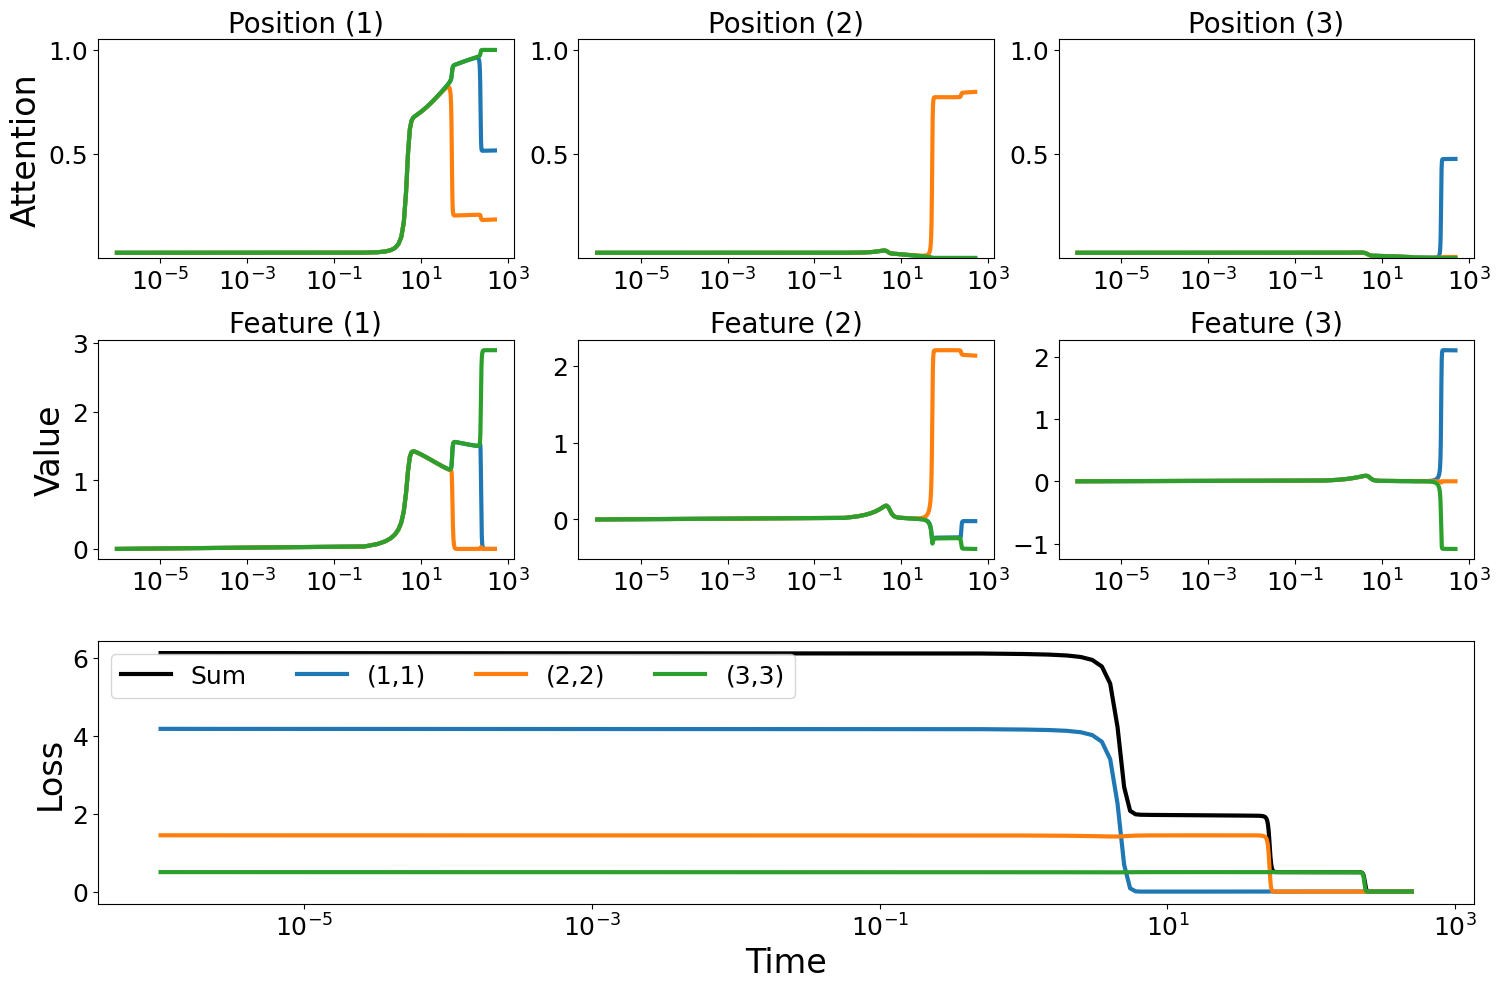

In [3]:
times = np.array([record["time"] for record in records]) + 1e-6
S = np.stack([record["s"][:, positions] for record in records])
V = np.stack([record["V"] for record in records])
loss = np.array([record["loss"] for record in records])
contrib = np.stack([record["contributions"] for record in records])
colors = REPORT_HEAD_COLORS

fig = plt.figure(figsize=(15, 10))
grid = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.2])

for pos_idx in range(3):
    ax = fig.add_subplot(grid[0, pos_idx])
    for head_idx, color in enumerate(colors):
        ax.semilogx(times, S[:, head_idx, pos_idx], color=color, linewidth=REPORT_LINEWIDTH, label=f"Head {head_idx + 1}")
    ax.set_ylim(1e-5, 1.05)
    style_report_axis(
        ax,
        xlabel=None,
        ylabel="Attention" if pos_idx == 0 else None,
        title=f"Position ({pos_idx + 1})",
    )

for feat_idx in range(3):
    ax = fig.add_subplot(grid[1, feat_idx])
    for head_idx, color in enumerate(colors):
        ax.semilogx(times, V[:, head_idx, feat_idx], color=color, linewidth=REPORT_LINEWIDTH, label=f"Head {head_idx + 1}")
    style_report_axis(
        ax,
        xlabel=None,
        ylabel="Value" if feat_idx == 0 else None,
        title=f"Feature ({feat_idx + 1})",
    )

ax = fig.add_subplot(grid[2, :])
ax.semilogx(times, loss, color="black", linewidth=REPORT_LINEWIDTH, label="Sum")
for idx, color in enumerate(colors):
    ax.semilogx(times, contrib[:, idx], color=color, linewidth=REPORT_LINEWIDTH, label=f"({idx + 1},{idx + 1})")
style_report_axis(ax, xlabel="Time", ylabel="Loss", legend=True, legend_kwargs={"ncol": 4})
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("gradient-flow-simulation.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
